<a href="https://colab.research.google.com/github/cliteka-cell/Absolute-Range-Moving-Average-Strategy/blob/main/Absolute_Range_Moving_Averages_Stategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

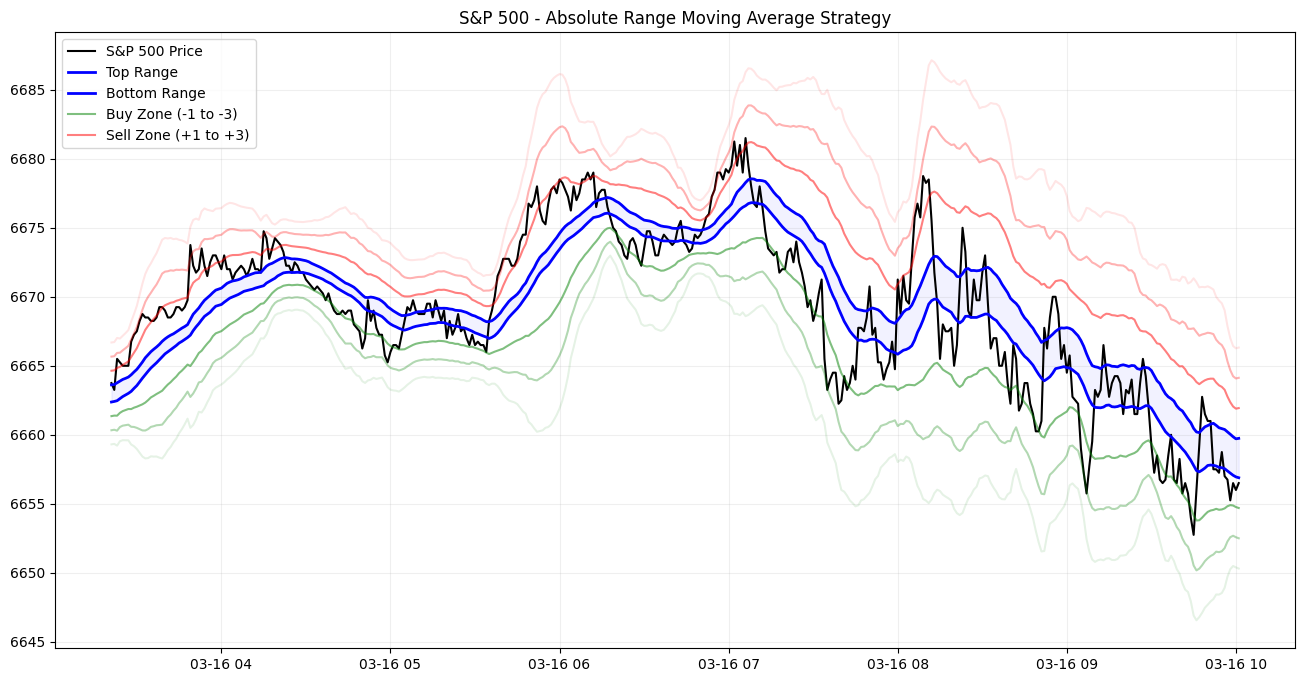

In [29]:
# Plotting the last 400 minutes to keep it readable
plot_df = df_7d.iloc[-400:]

plt.figure(figsize=(16, 8))

# Actual Price
plt.plot(plot_df.index, plot_df['Close'], label='S&P 500 Price', color='black', linewidth=1.5)

# The "No Trade Zone" Range
plt.plot(plot_df.index, plot_df['Top_Range'], color='blue', linewidth=2, label='Top Range')
plt.plot(plot_df.index, plot_df['Bottom_Range'], color='blue', linewidth=2, label='Bottom Range')
plt.fill_between(plot_df.index, plot_df['Top_Range'], plot_df['Bottom_Range'], color='blue', alpha=0.05)

# Buying Zones (Under the Bottom Range)
plt.plot(plot_df.index, plot_df['Lower_1'], color='green', alpha=0.5, label='Buy Zone (-1 to -3)')
plt.plot(plot_df.index, plot_df['Lower_2'], color='green', alpha=0.3)
plt.plot(plot_df.index, plot_df['Lower_3'], color='green', alpha=0.1)

# Selling Zones (Above the Top Range)
plt.plot(plot_df.index, plot_df['Upper_1'], color='red', alpha=0.5, label='Sell Zone (+1 to +3)')
plt.plot(plot_df.index, plot_df['Upper_2'], color='red', alpha=0.3)
plt.plot(plot_df.index, plot_df['Upper_3'], color='red', alpha=0.1)

plt.title('S&P 500 - Absolute Range Moving Average Strategy')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

In [30]:
import pandas as pd
import numpy as np
import yfinance as yf

df_7d = yf.download("ES=F", period="7d", interval="1m")
df_7d = df_7d[['High', 'Low', 'Close']].copy()

# --- Math Block ---
window = 30
df_7d['Top_Range'] = df_7d['High'].ewm(span=window, adjust=False).mean()
df_7d['Bottom_Range'] = df_7d['Low'].ewm(span=window, adjust=False).mean()
df_7d['Std'] = df_7d['Close'].rolling(window=window).std()

df_7d['Upper_1'] = df_7d['Top_Range'] + (df_7d['Std'] * 1)
df_7d['Upper_2'] = df_7d['Top_Range'] + (df_7d['Std'] * 2)
df_7d['Upper_3'] = df_7d['Top_Range'] + (df_7d['Std'] * 3)
df_7d['Stop_High'] = df_7d['Top_Range'] + (df_7d['Std'] * 4)

df_7d['Lower_1'] = df_7d['Bottom_Range'] - (df_7d['Std'] * 1)
df_7d['Lower_2'] = df_7d['Bottom_Range'] - (df_7d['Std'] * 2)
df_7d['Lower_3'] = df_7d['Bottom_Range'] - (df_7d['Std'] * 3)
df_7d['Stop_Low'] = df_7d['Bottom_Range'] - (df_7d['Std'] * 4)

df_7d = df_7d.dropna()

# --- Logic Block ---
detailed_trades_7d = []
long_inventory_7d = []
short_inventory_7d = []

bad_hours = [23, 2, 4, 6, 7]
# We use the fixed 2.0 points here because it's the $5000 Cash Index
min_width_7d = 2.0

for i in range(len(df_7d)):
    price = df_7d['Close'].iloc[i].item()
    current_time = df_7d.index[i]
    current_hour = current_time.hour

    top_range = df_7d['Top_Range'].iloc[i]
    bot_range = df_7d['Bottom_Range'].iloc[i]
    range_width = top_range - bot_range

    l1, l2, l3 = df_7d['Lower_1'].iloc[i], df_7d['Lower_2'].iloc[i], df_7d['Lower_3'].iloc[i]
    stop_low = df_7d['Stop_Low'].iloc[i]
    u1, u2, u3 = df_7d['Upper_1'].iloc[i], df_7d['Upper_2'].iloc[i], df_7d['Upper_3'].iloc[i]
    stop_high = df_7d['Stop_High'].iloc[i]

    # LONG
    if price <= stop_low and len(long_inventory_7d) > 0:
        for entry_time, entry_price in long_inventory_7d:
            detailed_trades_7d.append({'Entry_Time': entry_time, 'Profit': (price - entry_price) / entry_price})
        long_inventory_7d = []
    elif price >= bot_range and len(long_inventory_7d) > 0:
        for entry_time, entry_price in long_inventory_7d:
            detailed_trades_7d.append({'Entry_Time': entry_time, 'Profit': (price - entry_price) / entry_price})
        long_inventory_7d = []
    elif current_hour not in bad_hours and range_width >= min_width_7d:
        if price <= l3 and len(long_inventory_7d) == 2:
            long_inventory_7d.append((current_time, price))
        elif price <= l2 and len(long_inventory_7d) == 1:
            long_inventory_7d.append((current_time, price))
        elif price <= l1 and len(long_inventory_7d) == 0:
            long_inventory_7d.append((current_time, price))

    # SHORT
    if price >= stop_high and len(short_inventory_7d) > 0:
        for entry_time, entry_price in short_inventory_7d:
            detailed_trades_7d.append({'Entry_Time': entry_time, 'Profit': (entry_price - price) / entry_price})
        short_inventory_7d = []
    elif price <= top_range and len(short_inventory_7d) > 0:
        for entry_time, entry_price in short_inventory_7d:
            detailed_trades_7d.append({'Entry_Time': entry_time, 'Profit': (entry_price - price) / entry_price})
        short_inventory_7d = []
    elif current_hour not in bad_hours and range_width >= min_width_7d:
        if price >= u3 and len(short_inventory_7d) == 2:
            short_inventory_7d.append((current_time, price))
        elif price >= u2 and len(short_inventory_7d) == 1:
            short_inventory_7d.append((current_time, price))
        elif price >= u1 and len(short_inventory_7d) == 0:
            short_inventory_7d.append((current_time, price))

if len(detailed_trades_7d) > 0:
    trade_log_7d = pd.DataFrame(detailed_trades_7d)
    trade_log_7d['Cumulative_Return'] = (1 + trade_log_7d['Profit']).cumprod()

    wins = trade_log_7d[trade_log_7d['Profit'] > 0]

    total_return7d = 1.0
    for p in trade_log_7d['Profit']:
        total_return7d *= (1 + p)
    total_profit_pct7d = (total_return7d - 1) * 100

    trade_log_7d['Peak'] = trade_log_7d['Cumulative_Return'].cummax()
    trade_log_7d['Drawdown'] = (trade_log_7d['Cumulative_Return'] - trade_log_7d['Peak']) / trade_log_7d['Peak']

    max_drawdown = trade_log_7d['Drawdown'].min() * 100

    print("7- DAY DYNAMIC BACKTEST")
    print(f"Total Trades Taken: {len(trade_log_7d)}")
    print(f"Real Accuracy: {(len(wins)/len(trade_log_7d))*100:.1f}%")
    print(f"Real Compounded Profit: {total_profit_pct7d:.2f}%")
    print(f"Maximum Drawdown: {max_drawdown:.2f}%")
else:
    print("No trades happened.")


/tmp/ipykernel_213/774307677.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_7d = yf.download("ES=F", period="7d", interval="1m")
[*********************100%***********************]  1 of 1 completed


7- DAY DYNAMIC BACKTEST
Total Trades Taken: 280
Real Accuracy: 76.1%
Real Compounded Profit: 8.43%
Maximum Drawdown: -1.26%


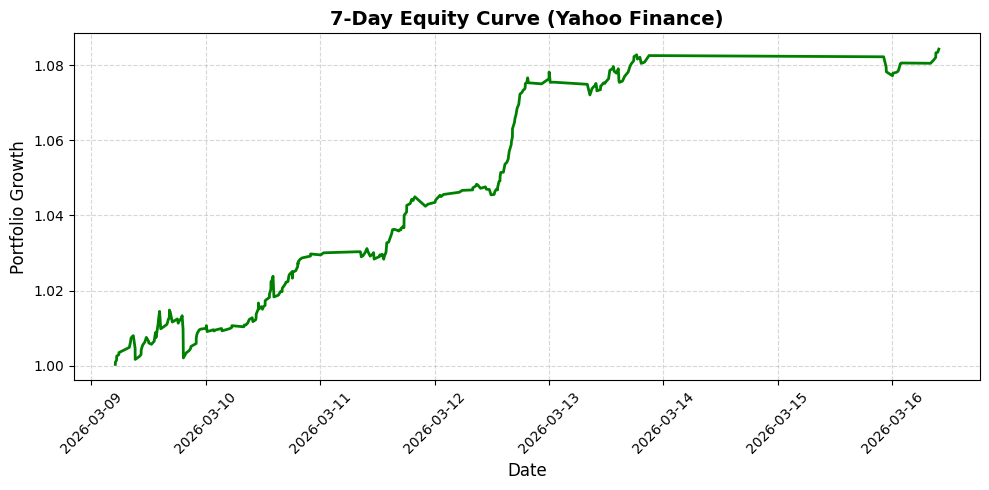

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Calculate the compound growth for the 7-day test
trade_log_7d['Cumulative_Return'] = (1 + trade_log_7d['Profit']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(trade_log_7d['Entry_Time'], trade_log_7d['Cumulative_Return'], color='green', linewidth=2)

plt.title('7-Day Equity Curve (Yahoo Finance)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Growth', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Now let us try this algorithm on a real 13-Years SPY data.**

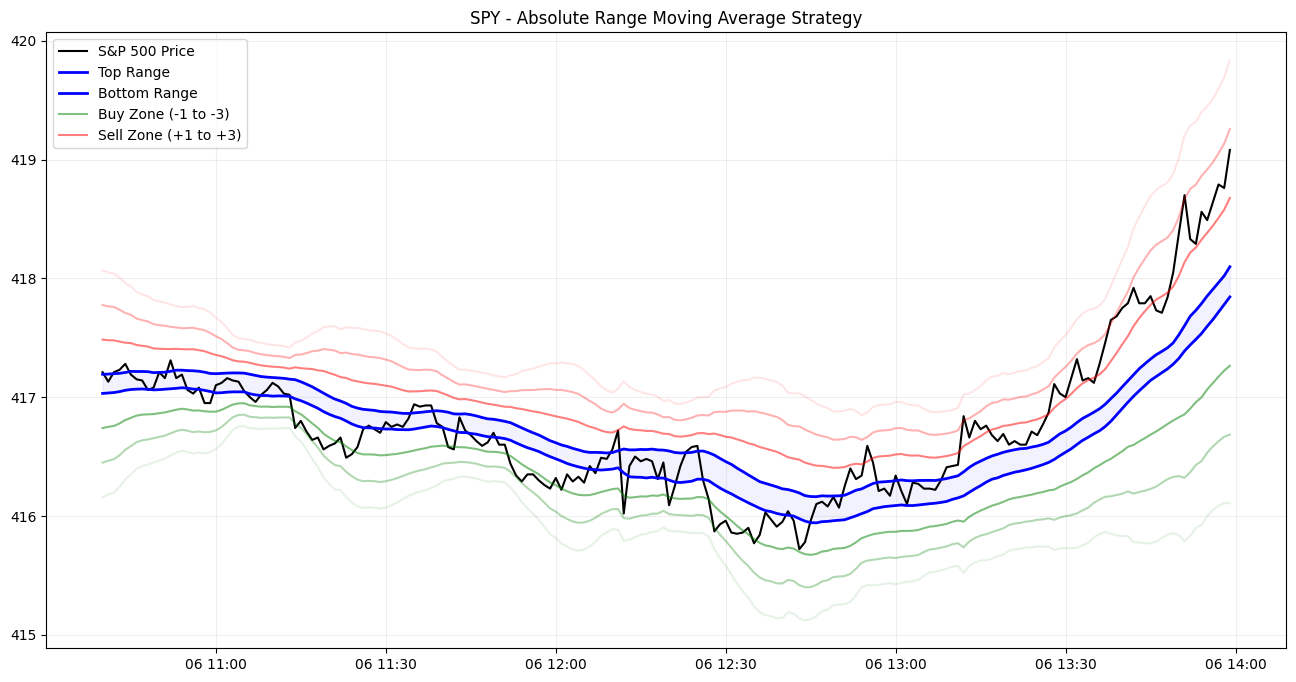

In [32]:
# Plotting the last 200 minutes to keep it readable
plot_df = df_13yr.iloc[-200:]

plt.figure(figsize=(16, 8))

# Actual Price
plt.plot(plot_df.index, plot_df['Close'], label='S&P 500 Price', color='black', linewidth=1.5)

# The "No Trade Zone" Range
plt.plot(plot_df.index, plot_df['Top_Range'], color='blue', linewidth=2, label='Top Range')
plt.plot(plot_df.index, plot_df['Bottom_Range'], color='blue', linewidth=2, label='Bottom Range')
plt.fill_between(plot_df.index, plot_df['Top_Range'], plot_df['Bottom_Range'], color='blue', alpha=0.05)

# Buying Zones (Under the Bottom Range)
plt.plot(plot_df.index, plot_df['Lower_1'], color='green', alpha=0.5, label='Buy Zone (-1 to -3)')
plt.plot(plot_df.index, plot_df['Lower_2'], color='green', alpha=0.3)
plt.plot(plot_df.index, plot_df['Lower_3'], color='green', alpha=0.1)

# Selling Zones (Above the Top Range)
plt.plot(plot_df.index, plot_df['Upper_1'], color='red', alpha=0.5, label='Sell Zone (+1 to +3)')
plt.plot(plot_df.index, plot_df['Upper_2'], color='red', alpha=0.3)
plt.plot(plot_df.index, plot_df['Upper_3'], color='red', alpha=0.1)

plt.title('SPY - Absolute Range Moving Average Strategy')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

In [36]:
print("Loading 13-year SPY data")
df_13yr = pd.read_csv("spy_1min_2008_2021_cleaned.csv")
df_13yr['date'] = pd.to_datetime(df_13yr['date'])
df_13yr.set_index('date', inplace=True)
df_13yr.rename(columns={'high': 'High', 'low': 'Low', 'close': 'Close'}, inplace=True)
df_13yr = df_13yr[['High', 'Low', 'Close']].copy()

# --- Math Block ---
window = 30
df_13yr['Top_Range'] = df_13yr['High'].ewm(span=window, adjust=False).mean()
df_13yr['Bottom_Range'] = df_13yr['Low'].ewm(span=window, adjust=False).mean()
df_13yr['Std'] = df_13yr['Close'].rolling(window=window).std()

df_13yr['Upper_1'] = df_13yr['Top_Range'] + (df_13yr['Std'] * 1)
df_13yr['Upper_2'] = df_13yr['Top_Range'] + (df_13yr['Std'] * 2)
df_13yr['Upper_3'] = df_13yr['Top_Range'] + (df_13yr['Std'] * 3)
df_13yr['Stop_High'] = df_13yr['Top_Range'] + (df_13yr['Std'] * 4)

df_13yr['Lower_1'] = df_13yr['Bottom_Range'] - (df_13yr['Std'] * 1)
df_13yr['Lower_2'] = df_13yr['Bottom_Range'] - (df_13yr['Std'] * 2)
df_13yr['Lower_3'] = df_13yr['Bottom_Range'] - (df_13yr['Std'] * 3)
df_13yr['Stop_Low'] = df_13yr['Bottom_Range'] - (df_13yr['Std'] * 4)

df_13yr = df_13yr.dropna()

# --- Logic Block ---
detailed_trades_13yr = []
long_inventory_13yr = []
short_inventory_13yr = []

bad_hours = [23, 2, 4, 6, 7]
# We use the percentage rule here because it's the SPY ETF
min_width_pct_13yr = 0.001

closes = df_13yr['Close'].values
top_ranges = df_13yr['Top_Range'].values
bot_ranges = df_13yr['Bottom_Range'].values
l1s, l2s, l3s, stop_lows = df_13yr['Lower_1'].values, df_13yr['Lower_2'].values, df_13yr['Lower_3'].values, df_13yr['Stop_Low'].values
u1s, u2s, u3s, stop_highs = df_13yr['Upper_1'].values, df_13yr['Upper_2'].values, df_13yr['Upper_3'].values, df_13yr['Stop_High'].values
times = df_13yr.index

for i in range(len(df_13yr)):
    price = closes[i]
    current_time = times[i]
    current_hour = current_time.hour

    top_range = top_ranges[i]
    bot_range = bot_ranges[i]
    range_width = top_range - bot_range

    l1, l2, l3, stop_low = l1s[i], l2s[i], l3s[i], stop_lows[i]
    u1, u2, u3, stop_high = u1s[i], u2s[i], u3s[i], stop_highs[i]

    dynamic_min_width = price * min_width_pct_13yr

    # LONG
    if price <= stop_low and len(long_inventory_13yr) > 0:
        for entry_time, entry_price in long_inventory_13yr:
            detailed_trades_13yr.append({'Entry_Time': entry_time, 'Profit': (price - entry_price) / entry_price})
        long_inventory_13yr = []
    elif price >= bot_range and len(long_inventory_13yr) > 0:
        for entry_time, entry_price in long_inventory_13yr:
            detailed_trades_13yr.append({'Entry_Time': entry_time, 'Profit': (price - entry_price) / entry_price})
        long_inventory_13yr = []
    elif current_hour not in bad_hours and range_width >= dynamic_min_width:
        if price <= l3 and len(long_inventory_13yr) == 2:
            long_inventory_13yr.append((current_time, price))
        elif price <= l2 and len(long_inventory_13yr) == 1:
            long_inventory_13yr.append((current_time, price))
        elif price <= l1 and len(long_inventory_13yr) == 0:
            long_inventory_13yr.append((current_time, price))

    # SHORT
    if price >= stop_high and len(short_inventory_13yr) > 0:
        for entry_time, entry_price in short_inventory_13yr:
            detailed_trades_13yr.append({'Entry_Time': entry_time, 'Profit': (entry_price - price) / entry_price})
        short_inventory_13yr = []
    elif price <= top_range and len(short_inventory_13yr) > 0:
        for entry_time, entry_price in short_inventory_13yr:
            detailed_trades_13yr.append({'Entry_Time': entry_time, 'Profit': (entry_price - price) / entry_price})
        short_inventory_13yr = []
    elif current_hour not in bad_hours and range_width >= dynamic_min_width:
        if price >= u3 and len(short_inventory_13yr) == 2:
            short_inventory_13yr.append((current_time, price))
        elif price >= u2 and len(short_inventory_13yr) == 1:
            short_inventory_13yr.append((current_time, price))
        elif price >= u1 and len(short_inventory_13yr) == 0:
            short_inventory_13yr.append((current_time, price))

if len(detailed_trades_13yr) > 0:
    trade_log_13yr = pd.DataFrame(detailed_trades_13yr)
    trade_log_13yr['Cumulative_Return'] = (1 + trade_log_13yr['Profit']).cumprod()

    wins = trade_log_13yr[trade_log_13yr['Profit'] > 0]

    total_return = 1.0
    for p in trade_log_13yr['Profit']:
        total_return *= (1 + p)
    total_profit_pct = (total_return - 1) * 100

    trade_log_13yr['Peak'] = trade_log_13yr['Cumulative_Return'].cummax()
    trade_log_13yr['Drawdown'] = (trade_log_13yr['Cumulative_Return'] - trade_log_13yr['Peak']) / trade_log_13yr['Peak']

    max_drawdown = trade_log_13yr['Drawdown'].min() * 100

    print("--- 13-YEAR DYNAMIC BACKTEST COMPLETE ---")
    print(f"Total Trades Taken: {len(trade_log_13yr)}")
    print(f"Real Accuracy: {(len(wins)/len(trade_log_13yr))*100:.1f}%")
    print(f"Real Compounded Profit: {total_profit_pct:.2f}%")
    print(f"Maximum Drawdown: {max_drawdown:.2f}%")
else:
    print("No trades happened.")


Loading 13-year SPY data
--- 13-YEAR DYNAMIC BACKTEST COMPLETE ---
Total Trades Taken: 10239
Real Accuracy: 68.0%
Real Compounded Profit: 3524.96%
Maximum Drawdown: -16.55%


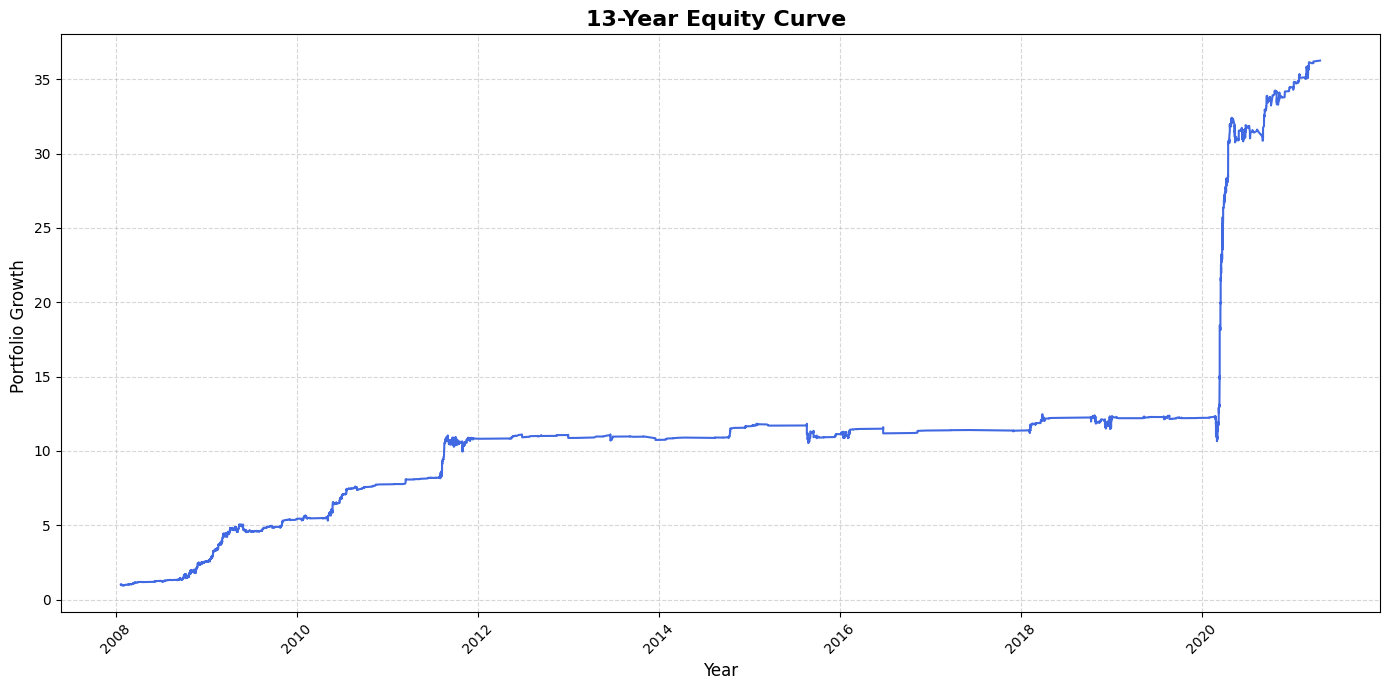

In [40]:
# Calculate the compound growth for the 13-year test

trade_log_13yr['Cumulative_Return'] = (1 + trade_log_13yr['Profit']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(trade_log_13yr['Entry_Time'], trade_log_13yr['Cumulative_Return'], color='royalblue', linewidth=1.5)

plt.title('13-Year Equity Curve ', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio Growth ', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

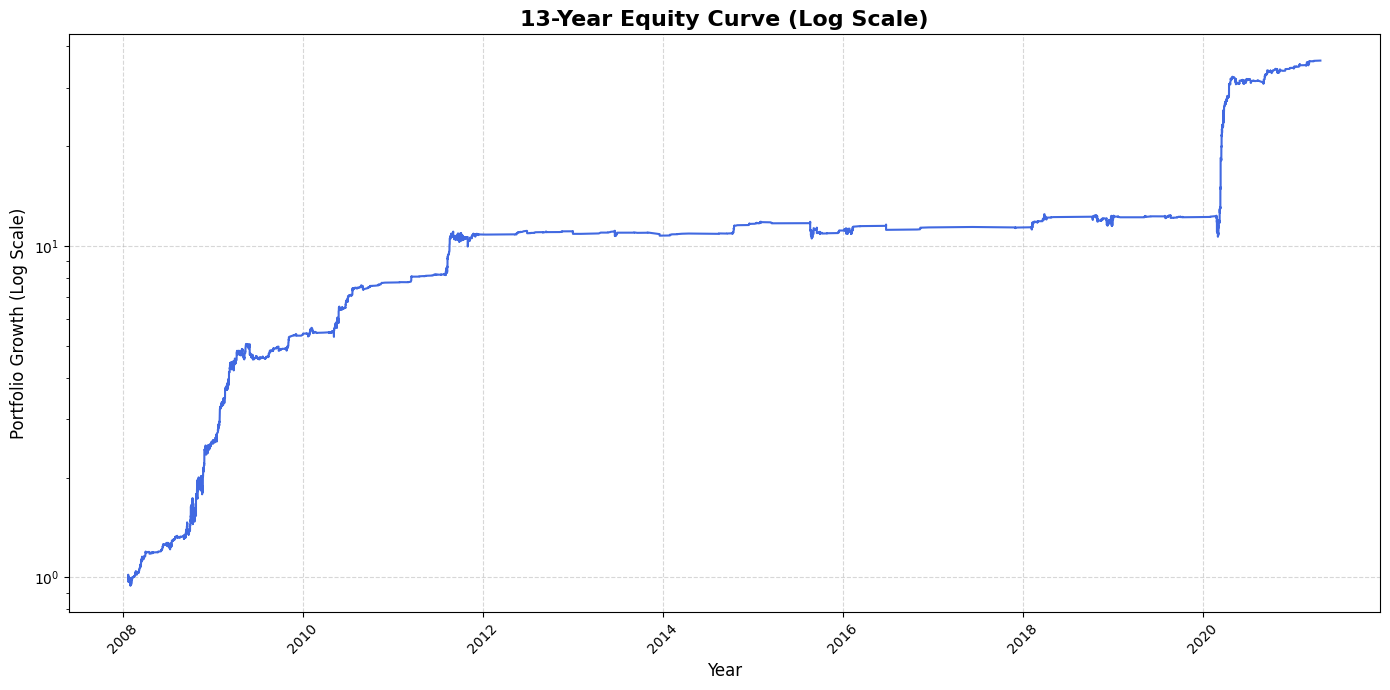

In [37]:
# Now the log scale
trade_log_13yr['Cumulative_Return'] = (1 + trade_log_13yr['Profit']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(trade_log_13yr['Entry_Time'], trade_log_13yr['Cumulative_Return'], color='royalblue', linewidth=1.5)

plt.yscale('log')

plt.title('13-Year Equity Curve (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio Growth (Log Scale)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
start_price = df_13yr['Close'].iloc[0]

end_price = df_13yr['Close'].iloc[-1]

buy_and_hold_return = ((end_price - start_price) / start_price) * 100

print("PERFORMANCE COMPARISON")
print(f"Algorithm Compounded Return 13 yrs: {total_profit_pct:.2f}%")
print(f"S&P 500 Buy & Hold Return 13 yrs: {buy_and_hold_return:.2f}%")
print(f"Algorithm Maximum Drawdown: {max_drawdown:.2f}%")

PERFORMANCE COMPARISON
Algorithm Compounded Return 13 yrs: 3524.96%
S&P 500 Buy & Hold Return 13 yrs: 226.06%
Algorithm Maximum Drawdown: -16.55%
